# RNN (GRU) Pattern Encoder

Trains a `SequenceGRU` on the binned stim -> spike dataset as a comparison to the
causal-CNN (TCN) models.  This notebook is the RNN-analogue of
`5k_dataset_icms150_hist_pillow.ipynb`, stripped of data-exploration cells: it
loads the data, builds train/val/test `BinnedStimSpikeDataset`s, initializes the
GRU from an explicit hyperparameter set, and trains it.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd


from utils import (
    make_spikes_responses_df,
    read_pattern_json,
    preprocess_pattern_stimulations_df,
)

# =====================
# Data location (defined here; this notebook does not read config.yaml HPs)
# =====================
datadir = "data/oracle_ICMS_150/"
# Neurons with very high firing rates (likely multi-unit / artifacts) to drop
problematic_neurons = [19, 104, 201, 211, 300, 310, 311, 312]

# Spikes (1 ms resolution)
spikes_df = make_spikes_responses_df(os.path.join(datadir, "SpkVecs.npy"))
spikes_df = spikes_df[~spikes_df["neuron_id"].isin(problematic_neurons)]
print(spikes_df["neuron_id"].nunique(), "unique neurons after dropping problematic neurons")

# Stimulation patterns
pattern_registrations_path = os.path.join(datadir, "pattern_registrations.pkl")
pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(
    read_pattern_json(pattern_registrations_path), align_to_stim=True
)
print("Loaded pattern_df with", len(pattern_df), "rows")


63 unique neurons after dropping problematic neurons
Loaded pattern_df with 97679 rows


In [2]:
# =====================
# Channel / neuron indexing
# =====================
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df["channel"].dropna().unique()))}

spiking_neurons = spikes_df["neuron_id"].unique()
spiking_neurons.sort()
spiking_neuron_to_index = {neuron: idx for idx, neuron in enumerate(spiking_neurons)}

print(f"Total unique stimulation channels: {len(channel_to_index)}")
print(f"Total spiking neurons: {len(spiking_neurons)}")


Total unique stimulation channels: 42
Total spiking neurons: 63


In [3]:
from utils import trial_breakout_spikes_and_patterns

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
    trial_breakout_spikes_and_patterns(
        spikes_df,
        pattern_df,
        channel_to_index,
        spiking_neurons=spiking_neurons,
        spiking_neuron_to_index=spiking_neuron_to_index,
    )
)

print(f"Total unique patterns: {len(pattern_stims)}")
print(f"Total trials (spike responses): {len(spike_responses)}")
print(f"Oracle trials: {unique_trials['is_oracle'].sum()}")


Total unique patterns: 4050
Total trials (spike responses): 5000
Oracle trials: 1000


## Hyperparameters

All settings for this run are defined explicitly below so the notebook is
self-contained.

**Neural feedback (TCN-style, per-step):** with `history > 0` the dataset
concatenates the lagged spike counts of all neurons onto the stimulation
channels at every 10 ms bin, so each recurrence step sees
`[ stim_k ; spike_history_k ]`.  This is the same mechanism the TCN uses with
`history > 0`, giving an apples-to-apples comparison.  History is teacher-forced
here (ground-truth lagged spikes); autoregressive / closed-loop feedback is a
later step.  Set `history = 0` to fall back to stimulation-only input.

**Initial state:** with `init_state = True` the dataset prepends
`n_initial_state_bins` pre-onset bins to the input (zero stimulation, but the
spike-history channels carry the previous trial's real activity).  The GRU
concatenates that whole pre-onset window — stim *and* history channels — and
projects it into its initial hidden state `h_0`, so the recurrence starts from a
learned latent rather than a cold zero state, matching how the TCN consumes its
prepended context.

In [4]:
# =====================
# Hyperparameter set
# =====================
HP = {
    # --- dataset / binning ---
    "input_bin_size_ms": 10,
    "output_bin_size_ms": 10,
    "n_input_bins": 60,        # stim bins fed to the GRU recurrence
    "n_output_bins": 60,       # spike bins predicted
    "output_offset": 0,
    "max_time_ms": 600,
    "encoding_mode": "current",   # 'current' or 'categorical'
    "history": 0,                 # lag (bins) of per-step neural feedback; 0 = stim only
    "split_mode": "oracle",       # 'oracle' or 'random'
    "seed": 42,
    "batch_size": 16,

    # --- initial state ---
    # Pre-onset bins prepended by the dataset (zero stim, no neural feedback)
    # that are concatenated and projected into the GRU's initial hidden state.
    "init_state": False,
    "n_initial_state_bins": 0,

    # --- GRU model ---
    "hidden_size": 128,
    "num_layers": 2,
    "embedding_dim": 0,        # 0/1 -> no embedding (use real-valued / current encoding)
    "fc_dims": [256],
    "dropout": 0.2,
    "bidirectional": False,    # keep False for causal stim->spike prediction

    # --- training ---
    "num_epochs": 50,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "weight_loss": 1,
    "sum_loss": False,
    "patience": 10,
    "criterion_fn": "poisson",
}
HP


{'input_bin_size_ms': 10,
 'output_bin_size_ms': 10,
 'n_input_bins': 60,
 'n_output_bins': 60,
 'output_offset': 0,
 'max_time_ms': 600,
 'encoding_mode': 'current',
 'history': 0,
 'split_mode': 'oracle',
 'seed': 42,
 'batch_size': 16,
 'init_state': False,
 'n_initial_state_bins': 0,
 'hidden_size': 128,
 'num_layers': 2,
 'embedding_dim': 0,
 'fc_dims': [256],
 'dropout': 0.2,
 'bidirectional': False,
 'num_epochs': 50,
 'learning_rate': 0.001,
 'weight_decay': 0.0,
 'weight_loss': 1,
 'sum_loss': False,
 'patience': 10,
 'criterion_fn': 'poisson'}

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import logging

from utils import BinnedStimSpikeDataset, NUM_STIM_LEVELS

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger("rnn_pattern_encoder")

SEED = HP["seed"]
torch.manual_seed(SEED)
np.random.seed(SEED)

# =====================
# Train / Val / Test splits
# =====================
all_timing_indices = list(spike_responses.keys())
unique_trials_info = pattern_df[["pattern_timing_index", "pattern_name", "is_oracle"]].drop_duplicates()

if HP["split_mode"] == "oracle":
    oracle_timing_indices = unique_trials_info[unique_trials_info["is_oracle"]]["pattern_timing_index"].tolist()
    sample_timing_indices = unique_trials_info[~unique_trials_info["is_oracle"]]["pattern_timing_index"].tolist()
    test_indices = oracle_timing_indices
    train_indices, val_indices = train_test_split(sample_timing_indices, test_size=0.15, random_state=SEED)
else:  # random
    train_val_indices, test_indices = train_test_split(all_timing_indices, test_size=0.15, random_state=SEED)
    train_indices, val_indices = train_test_split(train_val_indices, test_size=0.176, random_state=SEED)

logger.info(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

# =====================
# Datasets
# =====================
def make_dataset(trial_indices):
    return BinnedStimSpikeDataset(
        pattern_df, spike_responses, channel_to_index, timing_to_pattern,
        trial_indices=trial_indices,
        input_bin_size_ms=HP["input_bin_size_ms"],
        output_bin_size_ms=HP["output_bin_size_ms"],
        n_input_bins=HP["n_input_bins"],
        n_output_bins=HP["n_output_bins"],
        max_time_ms=HP["max_time_ms"],
        output_offset=HP["output_offset"],
        encoding_mode=HP["encoding_mode"],
        history=HP["history"],
        init_state=HP["init_state"],
        n_initial_state_bins=HP["n_initial_state_bins"],
        logger=logger,
    )

train_dataset = make_dataset(train_indices)
val_dataset = make_dataset(val_indices)
test_dataset = make_dataset(test_indices)

train_loader = DataLoader(train_dataset, batch_size=HP["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=HP["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=HP["batch_size"], shuffle=False)

logger.info(f"Train samples: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

n_stim_channels = train_dataset.n_channels
n_neurons = train_dataset.n_neurons

# With spike history (history > 0) the dataset concatenates n_neurons history
# channels onto the stim channels, so the model sees more input channels.
if HP["history"] and HP["history"] > 0:
    n_model_input_channels = n_stim_channels + n_neurons
else:
    n_model_input_channels = n_stim_channels

logger.info(f"Stim channels: {n_stim_channels} | model input channels: {n_model_input_channels} | neurons: {n_neurons}")


2026-06-16 12:46:27,584 - INFO - Train: 3400, Val: 600, Test: 1000
2026-06-16 12:46:41,157 - INFO - BinnedStimSpikeDataset initialized:
2026-06-16 12:46:41,157 - INFO -   input_bin_size_ms=10, output_bin_size_ms=10
2026-06-16 12:46:41,157 - INFO -   n_input_bins=60, n_output_bins=60
2026-06-16 12:46:41,158 - INFO -   output_offset=0, total_bins_input=60, total_bins_output=60
2026-06-16 12:46:41,158 - INFO -   Valid start positions per trial: 0 to 0
2026-06-16 12:46:41,158 - INFO -   Total samples: 3400 (3400 trials × 1 positions)


0 trials were added in spike responses for initial state that were not in the specified trial_indices


2026-06-16 12:46:54,580 - INFO - BinnedStimSpikeDataset initialized:
2026-06-16 12:46:54,581 - INFO -   input_bin_size_ms=10, output_bin_size_ms=10
2026-06-16 12:46:54,581 - INFO -   n_input_bins=60, n_output_bins=60
2026-06-16 12:46:54,581 - INFO -   output_offset=0, total_bins_input=60, total_bins_output=60
2026-06-16 12:46:54,581 - INFO -   Valid start positions per trial: 0 to 0
2026-06-16 12:46:54,581 - INFO -   Total samples: 600 (600 trials × 1 positions)


0 trials were added in spike responses for initial state that were not in the specified trial_indices


2026-06-16 12:47:07,859 - INFO - BinnedStimSpikeDataset initialized:
2026-06-16 12:47:07,859 - INFO -   input_bin_size_ms=10, output_bin_size_ms=10
2026-06-16 12:47:07,860 - INFO -   n_input_bins=60, n_output_bins=60
2026-06-16 12:47:07,860 - INFO -   output_offset=0, total_bins_input=60, total_bins_output=60
2026-06-16 12:47:07,860 - INFO -   Valid start positions per trial: 0 to 0
2026-06-16 12:47:07,860 - INFO -   Total samples: 1000 (1000 trials × 1 positions)
2026-06-16 12:47:07,860 - INFO - Train samples: 3400, Val: 600, Test: 1000
2026-06-16 12:47:07,861 - INFO - Stim channels: 42 | model input channels: 42 | neurons: 63


0 trials were added in spike responses for initial state that were not in the specified trial_indices


In [6]:
# =====================
# Device
# =====================
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
else:
    device = torch.device("cpu")
logger.info(f"Using device: {device}")

# Output directory for this run's artifacts / figures
from datetime import datetime
RUN_DIR = os.path.join("results", datetime.now().strftime("gru_%Y-%m-%d_%H-%M-%S"))
os.makedirs(RUN_DIR, exist_ok=True)
logger.info(f"Run directory: {RUN_DIR}")


2026-06-16 12:47:08,009 - INFO - Using device: cuda
2026-06-16 12:47:08,009 - INFO - Run directory: results/gru_2026-06-16_12-47-08


## Initialize GRU and sanity-check a forward pass

In [7]:
from models import get_model

model = get_model(
    "gru",
    n_stim_channels=n_model_input_channels,
    n_neurons=n_neurons,
    n_input_bins=HP["n_input_bins"],
    n_output_bins=HP["n_output_bins"],
    hidden_size=HP["hidden_size"],
    num_layers=HP["num_layers"],
    embedding_dim=HP["embedding_dim"],
    fc_dims=HP["fc_dims"],
    dropout=HP["dropout"],
    num_stim_levels=NUM_STIM_LEVELS,
    bidirectional=HP["bidirectional"],
    init_state=HP["init_state"],
    n_initial_state_bins=HP["n_initial_state_bins"],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
logger.info(f"SequenceGRU initialized | {total_params:,} parameters")

# Forward-pass shape check against a real batch
sample_x, sample_y = next(iter(train_loader))
sample_x = sample_x.to(device)
with torch.no_grad():
    sample_out = model(sample_x)
print(f"Input:  {tuple(sample_x.shape)}")
print(f"Output: {tuple(sample_out.shape)}")
print(f"Target: {tuple(sample_y.shape)}")
assert sample_out.shape[1:] == sample_y.shape[1:], (
    f"Shape mismatch! Output {sample_out.shape} vs target {sample_y.shape}"
)
print("✓ Output and target shapes match")


2026-06-16 12:47:08,162 - INFO - SequenceGRU initialized | 214,335 parameters


Input:  (16, 42, 60)
Output: (16, 63, 60)
Target: (16, 63, 60)
✓ Output and target shapes match


## Train

In [8]:
from models import train_epoch, validate
from tqdm import tqdm

# Loss
if HP["criterion_fn"] == "poisson":
    criterion = nn.PoissonNLLLoss(log_input=True, reduction="none", full=True)
else:
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([HP["weight_loss"]], device=device), reduction="none"
    )

optimizer = torch.optim.AdamW(model.parameters(), lr=HP["learning_rate"], weight_decay=HP["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

history = {"train_loss": [], "val_loss": [], "val_corr": [], "lr": []}
best_val_corr = -float("inf")
patience_counter = 0
model_save_path = "best_gru_model.pt"

epoch_pbar = tqdm(range(HP["num_epochs"]), desc="Epochs")
for epoch in epoch_pbar:
    train_loss = train_epoch(
        model, train_loader, criterion, optimizer, device,
        sum_loss=HP["sum_loss"], grad_clip=False, weight_loss=HP["weight_loss"],
        use_init_state=False,
    )
    val_loss, val_corr = validate(
        model, val_loader, criterion, device,
        sum_loss=HP["sum_loss"], weight_loss=HP["weight_loss"], use_init_state=False,
    )
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_corr"].append(val_corr)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    epoch_pbar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "val_loss": f"{val_loss:.4f}",
        "val_corr": f"{val_corr:.4f}",
    })
    logger.info(
        f"Epoch {epoch+1:3d}/{HP['num_epochs']} | train {train_loss:.4f} | "
        f"val {val_loss:.4f} | val_corr {val_corr:.4f} | lr {optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_corr > best_val_corr:
        best_val_corr = val_corr
        patience_counter = 0
        torch.save(model.state_dict(), model_save_path)
    else:
        patience_counter += 1
        if patience_counter >= HP["patience"]:
            logger.info(f"Early stopping at epoch {epoch+1}")
            break

logger.info(f"Training complete. Best val correlation: {best_val_corr:.4f}")


Epochs: 100%|██████████| 50/50 [00:26<00:00,  1.91it/s, train_loss=0.1530, val_loss=0.1634, val_corr=0.3106]
2026-06-16 12:47:34,859 - INFO - Training complete. Best val correlation: 0.3110


## Evaluate on test set

Test loss: 0.156376
Test corr: 0.307681


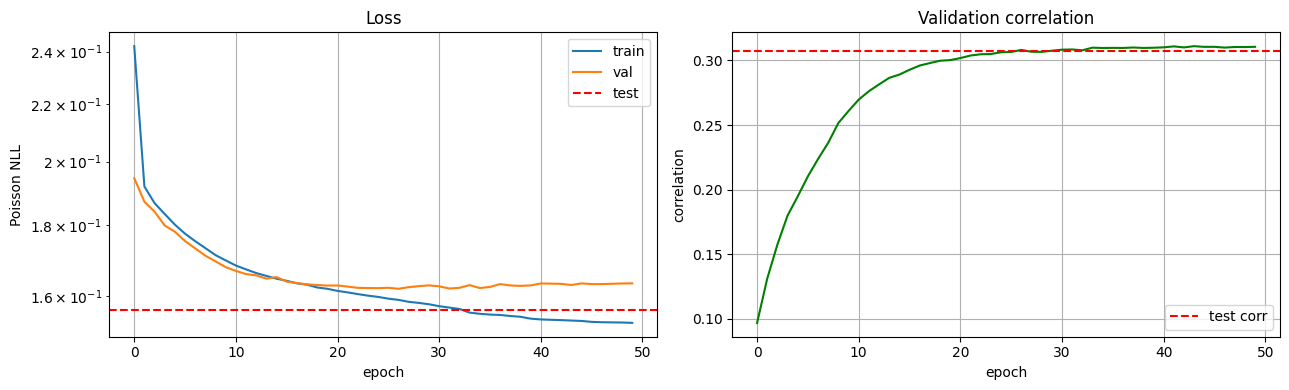

In [9]:
import matplotlib.pyplot as plt

# Load best checkpoint
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_corr = validate(
    model, test_loader, criterion, device,
    sum_loss=HP["sum_loss"], weight_loss=HP["weight_loss"], use_init_state=False,
)
print(f"Test loss: {test_loss:.6f}")
print(f"Test corr: {test_corr:.6f}")

# Loss / correlation curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].axhline(test_loss, color="red", ls="--", label="test")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("Poisson NLL"); axes[0].set_yscale("log")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history["val_corr"], color="green")
axes[1].axhline(test_corr, color="red", ls="--", label="test corr")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("correlation")
axes[1].set_title("Validation correlation"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()


## Oracle prediction visualizations

The same four oracle plots used for the TCN, reusing the functions in `viz.py`.

> The GRU consumes its initial-state context *inside* `x` (and produces a
> 2-tuple dataset), so all viz calls use `use_init_state=False` — the model is
> invoked exactly like the CNN via `model(batch_x)`.

2026-06-16 12:47:35,526 - INFO - Correlation between predicted and actual per-neuron averages: r=0.9898, p=0.00e+00


Test predictions: (1000, 63, 60) targets: (1000, 63, 60)


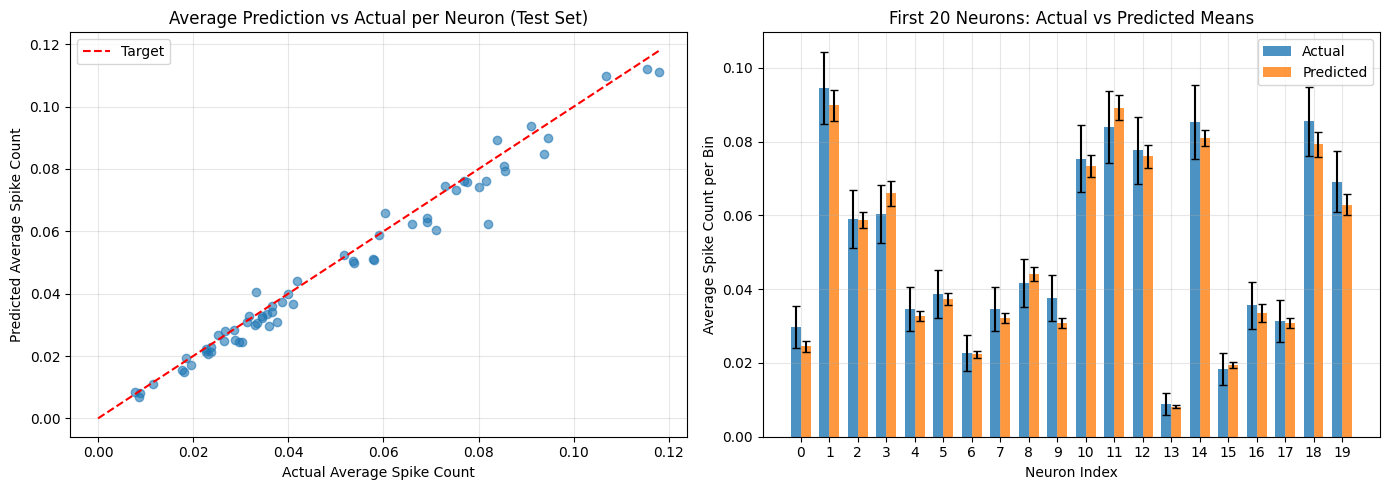

In [10]:
from viz import plot_test_prediction_comparison

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for batch in test_loader:
        batch_x, batch_y = batch[:2]
        all_preds.append(model(batch_x.to(device)).cpu())
        all_targets.append(batch_y)
all_preds = torch.cat(all_preds, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()
print("Test predictions:", all_preds.shape, "targets:", all_targets.shape)

fig, axes, corr, pval = plot_test_prediction_comparison(
    all_preds, all_targets,
    savepath=os.path.join(RUN_DIR, "test_prediction_comparison.png"),
    logger=logger,
)
plt.show()


Found 50 unique oracle patterns in test set
Samples per pattern: min=20, max=20, mean=20.0
Patterns: 50 | true range [0.0000, 0.3100] | pred range [0.0017, 0.3273]


2026-06-16 12:47:36,350 - INFO - Pattern selectivity summary:
2026-06-16 12:47:36,350 - INFO -   Mean correlation across neurons: 0.6446
2026-06-16 12:47:36,351 - INFO -   Median correlation: 0.6656
2026-06-16 12:47:36,351 - INFO -   Neurons with r > 0.5: 51 / 63
2026-06-16 12:47:36,351 - INFO -   Neurons with r > 0.3: 60 / 63


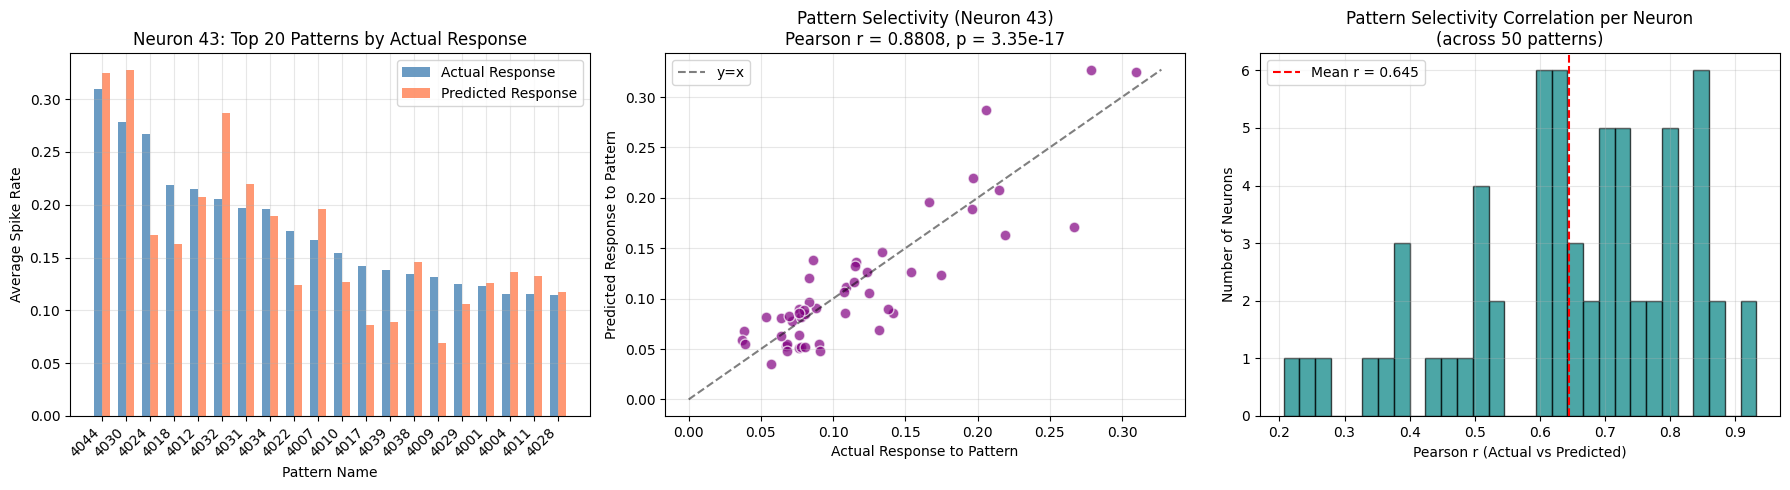

Mean per-neuron correlation: 0.6446 | median: 0.6656 | r>0.5: 51/63


In [11]:
from viz import analyze_pattern_responses_by_pattern_name, plot_pattern_selectivity

# Average predicted vs true response per oracle pattern
pattern_names, pat_true, pat_pred, pat_counts = analyze_pattern_responses_by_pattern_name(
    model, test_dataset, device, use_init_state=False,
)
print(f"Patterns: {len(pattern_names)} | "
      f"true range [{pat_true.min():.4f}, {pat_true.max():.4f}] | "
      f"pred range [{pat_pred.min():.4f}, {pat_pred.max():.4f}]")

fig, axes, neuron_correlations = plot_pattern_selectivity(
    pattern_names, pat_true, pat_pred,
    savepath=os.path.join(RUN_DIR, "pattern_selectivity_analysis.png"),
    logger=logger,
)
plt.show()
print(f"Mean per-neuron correlation: {np.mean(neuron_correlations):.4f} | "
      f"median: {np.median(neuron_correlations):.4f} | "
      f"r>0.5: {(neuron_correlations > 0.5).sum()}/{len(neuron_correlations)}")


In [ ]:
from viz import plot_oracle_trials_by_pattern

# Per-pattern figures: model prediction overlaid on the oracle (trial-averaged) response.
plot_oracle_trials_by_pattern(
    model=model,
    test_dataset=test_dataset,
    pattern_df=pattern_df,
    spike_responses=spike_responses,
    pattern_polarities=pattern_polarities,
    output_bin_size_ms=HP["output_bin_size_ms"],
    n_input_bins=HP["n_input_bins"],
    n_output_bins=HP["n_output_bins"],
    output_offset=HP["output_offset"],
    max_time_ms=HP["max_time_ms"],
    n_neurons=n_neurons,
    device=device,
    out_base=os.path.join(RUN_DIR, "oracle_trials_by_pattern"),
    input_bin_size_ms=HP["input_bin_size_ms"],
    logger=logger,
    pattern_limit=50,
    use_init_state=False,
    n_initial_state_bins=HP["n_initial_state_bins"],
    history=HP["history"],
    init_state=HP["init_state"],
)
print("Saved per-pattern oracle figures to", os.path.join(RUN_DIR, "oracle_trials_by_pattern"))


2026-06-16 12:47:36,512 - INFO - Found 50 oracle patterns
2026-06-16 12:47:36,513 - INFO - Using input_bin_size=10ms, output_bin_size=10ms, n_input_bins=60, n_output_bins=60, output_offset=0
2026-06-16 12:47:36,513 - INFO - Total input bins: 60, Total output bins: 60
2026-06-16 12:47:36,513 - INFO - Valid input positions: 0 to 0
2026-06-16 12:47:36,954 - INFO - Saved pattern 4033 trial 0 figure to results/gru_2026-06-16_12-47-08/oracle_trials_by_pattern/pattern_4033/trial_00_timing_0.jpg
2026-06-16 12:47:42,540 - INFO - Completed pattern 4033 (1/50)
2026-06-16 12:47:42,825 - INFO - Saved pattern 4017 trial 0 figure to results/gru_2026-06-16_12-47-08/oracle_trials_by_pattern/pattern_4017/trial_00_timing_1.jpg
2026-06-16 12:47:48,518 - INFO - Completed pattern 4017 (2/50)
2026-06-16 12:47:48,802 - INFO - Saved pattern 4028 trial 0 figure to results/gru_2026-06-16_12-47-08/oracle_trials_by_pattern/pattern_4028/trial_00_timing_2.jpg
2026-06-16 12:47:54,541 - INFO - Completed pattern 4028 (

## Save summary metrics

Writes `summary_metrics.json`, `training_history.json`, and `per_neuron_metrics.npz`
into `RUN_DIR`, mirroring `run_experiment.py` so GRU runs are directly comparable
to the TCN/CNN baselines. Reuses the `metrics.py` helpers (`get_per_neuron_temporal_corr`,
`collect_model_preds_and_targets`, `fraction_variance_explained`). The headline
metric is the **test-set correlation** (per-neuron temporal Pearson r, mean over neurons).

In [ ]:
import json
from metrics import (
    get_per_neuron_temporal_corr,
    collect_model_preds_and_targets,
    fraction_variance_explained,
)

# Per-neuron temporal correlation across the full test set (concatenated trials x time).
# This is the headline test-set correlation, computed the same way as for the TCN/CNN.
model_tuple = (model, None, device)
neuron_test_corrs = get_per_neuron_temporal_corr(model_tuple, test_loader)
all_test_corr = float(np.mean(neuron_test_corrs))
median_test_corr = float(np.median(neuron_test_corrs))

# Predictions / targets for FVE (model emits log-rates; helper applies exp -> rates)
all_preds_rates, all_targets_fve = collect_model_preds_and_targets(model_tuple, test_loader)
neuron_fve_global, fve_global_mean = fraction_variance_explained(
    all_targets_fve, all_preds_rates, global_variance=True
)
neuron_fve_local, fve_local_mean = fraction_variance_explained(
    all_targets_fve, all_preds_rates, global_variance=False
)

logger.info(f"Test corr (per-neuron mean): {all_test_corr:.6f} | median: {median_test_corr:.6f}")
logger.info(f"FVE (global, per-neuron mean): {fve_global_mean:.6f} | median: {float(np.median(neuron_fve_global)):.6f}")
logger.info(f"FVE (local/within-trial, per-neuron mean): {fve_local_mean:.6f} | median: {float(np.median(neuron_fve_local)):.6f}")

# Mean per-pattern selectivity correlation (from the pattern-selectivity cell, if run)
mean_pattern_corr = float(np.mean(neuron_correlations)) if "neuron_correlations" in dir() else float("nan")

# Save training history
with open(os.path.join(RUN_DIR, "training_history.json"), "w") as f:
    json.dump(history, f, indent=2)

summary = {
    "run_dir": RUN_DIR,
    "model_type": "gru",
    "batch_avg_test_loss": float(test_loss),
    "batch_avg_test_corr": float(test_corr),
    "all_test_corr": all_test_corr,                  # per-neuron temporal corr, mean over neurons
    "median_test_corr": median_test_corr,
    "all_test_fve_global": float(fve_global_mean),   # per-neuron FVE, variance across all trials
    "all_test_fve_local": float(fve_local_mean),     # per-neuron FVE, variance within each trial
    "best_val_corr": float(best_val_corr),
    "mean_pattern_corr": mean_pattern_corr,
    "total_params": total_params,
    "epochs_trained": len(history["train_loss"]),
    "history": HP["history"],
    "init_state": HP["init_state"],
    # --- GRU architecture / training config ---
    "hidden_size": HP["hidden_size"],
    "num_layers": HP["num_layers"],
    "embedding_dim": HP["embedding_dim"],
    "fc_dims": HP["fc_dims"],
    "dropout": HP["dropout"],
    "bidirectional": HP["bidirectional"],
    "n_initial_state_bins": HP["n_initial_state_bins"],
    "encoding_mode": HP["encoding_mode"],
    "learning_rate": HP["learning_rate"],
    "weight_decay": HP["weight_decay"],
    "batch_size": HP["batch_size"],
    "criterion_fn": HP["criterion_fn"],
}

with open(os.path.join(RUN_DIR, "summary_metrics.json"), "w") as f:
    json.dump(summary, f, indent=2)

# Per-neuron arrays for downstream analysis
np.savez(
    os.path.join(RUN_DIR, "per_neuron_metrics.npz"),
    neuron_test_corrs=neuron_test_corrs,
    neuron_fve_global=neuron_fve_global,
    neuron_fve_local=neuron_fve_local,
)

logger.info(f"Summary metrics saved to {RUN_DIR}/summary_metrics.json")
print(json.dumps(summary, indent=2))

## 5-fold CV comparison: TCN ± history vs GRU ± history

Trains 4 models (TCN/GRU × history on/off) under 5-fold CV. Train pool is the
non-oracle trials; the validation split is resampled per fold; every model is
evaluated on the fixed oracle test set. fc_dims=[512] for all models; TCN conv
channels are tuned to match the GRU no-history parameter count (±5%). Bars show
mean ± standard error over the 5 folds.

In [17]:
# ---- CV comparison config ----
CV_EPOCHS = HP["num_epochs"]
CV_PATIENCE = HP["patience"]
N_FOLDS = 5
FC_DIMS = [512]
CV_HISTORY = HP["history"] if HP["history"] > 0 else 1   # 10ms teacher-forced lag for history-on models

def count_params(m):
    return sum(p.numel() for p in m.parameters())

# Fixed GRU config (reference for param matching)
def build_gru(history):
    in_ch = n_stim_channels + (n_neurons if history else 0)
    return get_model(
        "gru",
        n_stim_channels=in_ch, n_neurons=n_neurons,
        n_input_bins=HP["n_input_bins"], n_output_bins=HP["n_output_bins"],
        hidden_size=128, num_layers=2, embedding_dim=0,
        fc_dims=FC_DIMS, dropout=HP["dropout"],
        num_stim_levels=NUM_STIM_LEVELS, bidirectional=False,
        init_state=False, n_initial_state_bins=0,
    )

def build_tcn(history, conv_channels):
    in_ch = n_stim_channels + (n_neurons if history else 0)
    return get_model(
        "cnn",
        n_stim_channels=in_ch, n_neurons=n_neurons,
        n_input_bins=HP["n_input_bins"], n_output_bins=HP["n_output_bins"],
        embedding_dim=0, conv_channels=conv_channels, kernel_sizes=[3, 3],
        fc_dims=FC_DIMS, dropout=HP["dropout"], num_stim_levels=NUM_STIM_LEVELS,
        use_batch_norm=True, use_init_state=False,
    )

# Target: GRU no-history param count
gru_target = count_params(build_gru(history=False))

# Search a single conv width w (both layers = w) so TCN no-hist params ~ gru_target
best_w, best_diff = None, float("inf")
for w in range(8, 513, 2):
    p = count_params(build_tcn(history=False, conv_channels=[w, w]))
    diff = abs(p - gru_target)
    if diff < best_diff:
        best_diff, best_w = diff, w
TCN_CONV = [best_w, best_w]

GRU_KW = dict(builder=build_gru)
TCN_KW = dict(builder=lambda history: build_tcn(history, TCN_CONV), conv_channels=TCN_CONV)

MODEL_SPECS = [
    ("GRU_nohist", "gru", False),
    ("GRU_hist",   "gru", True),
    ("TCN_nohist", "cnn", False),
    ("TCN_hist",   "cnn", True),
]

# Report actual counts AND a succinct architecture summary for all four
print(f"GRU no-hist target params: {gru_target:,}")
print(f"TCN conv channels chosen: {TCN_CONV} (within {100*best_diff/gru_target:.1f}% of target)")
for name, arch, hist in MODEL_SPECS:
    m = build_gru(hist) if arch == "gru" else build_tcn(hist, TCN_CONV)
    in_ch = n_stim_channels + (n_neurons if hist else 0)
    print(f"\n{'='*60}\n{name}  |  in_ch={in_ch}  |  {count_params(m):,} params")
    print("-" * 60)
    # repr(model) is PyTorch's built-in module summary (layers + shapes)
    print(m)
    del m
assert best_diff / gru_target <= 0.05, f"TCN no-hist not within 5% of GRU ({best_diff/gru_target:.1%})"

GRU no-hist target params: 263,487
TCN conv channels chosen: [190, 190] (within 0.0% of target)

GRU_nohist  |  in_ch=42  |  263,487 params
------------------------------------------------------------
SequenceGRU(
  (embedding): Identity()
  (gru): GRU(42, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=63, bias=True)
  )
)

GRU_hist  |  in_ch=105  |  287,679 params
------------------------------------------------------------
SequenceGRU(
  (embedding): Identity()
  (gru): GRU(105, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=63, bias=True)
  )
)

TCN_nohist  |  in_ch=42  |  263,491 params
------------------------------

In [ ]:
# ---- Precompute binned caches ONCE (shared across all folds/models) ----
# The heavy part of BinnedStimSpikeDataset.__init__ is (a) re-encoding every
# unique pattern via .iterrows() and (b) re-binning every trial's spikes. Both
# are independent of the fold split AND of the history setting (history only
# changes how __getitem__ assembles the sample). So we build them a single time
# over ALL patterns/trials and have each fold's dataset just index into them.
#
# CV uses init_state=False and output_offset=0, with n_input_bins==n_output_bins
# == total_bins (60) -> exactly one (timing_idx, t=0) sample per trial.
import time as _time
from utils import BinnedStimSpikeDataset, bin_spike_response

_t0 = _time.time()

# Build one full dataset to harvest its precomputed encodings (history-agnostic).
_full_idx = list(spike_responses.keys())
_full_ds = BinnedStimSpikeDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    trial_indices=_full_idx,
    input_bin_size_ms=HP["input_bin_size_ms"], output_bin_size_ms=HP["output_bin_size_ms"],
    n_input_bins=HP["n_input_bins"], n_output_bins=HP["n_output_bins"],
    max_time_ms=HP["max_time_ms"], output_offset=HP["output_offset"],
    encoding_mode=HP["encoding_mode"], history=0,
    init_state=False, n_initial_state_bins=0, logger=logger,
)
SHARED_PATTERN_STIMS = _full_ds.pattern_stims                # pattern_name -> (n_chan, total_bins)
SHARED_SPIKES_BINNED = _full_ds.spike_responses_binned       # timing_idx   -> (n_neurons, total_bins)
logger.info(f"Precomputed shared caches in {_time.time()-_t0:.1f}s "
            f"({len(SHARED_PATTERN_STIMS)} patterns, {len(SHARED_SPIKES_BINNED)} trials)")


class FastBinnedDataset(BinnedStimSpikeDataset):
    """BinnedStimSpikeDataset that reuses precomputed pattern/spike caches.

    Skips the expensive per-pattern .iterrows() encoding and per-trial spike
    binning in the parent __init__; only builds the lightweight (timing_idx, t)
    sample list for this fold. __getitem__/__len__ are inherited unchanged.
    Assumes init_state=False (the CV setting).
    """
    def __init__(self, trial_indices, history, pattern_stims, spike_responses_binned,
                 timing_to_pattern, channel_to_index, n_neurons):
        self.trial_indices = trial_indices
        self.timing_to_pattern = timing_to_pattern
        self.encoding_mode = HP["encoding_mode"]
        self.n_channels = len(channel_to_index)
        self.input_bin_size = HP["input_bin_size_ms"]
        self.output_bin_size = HP["output_bin_size_ms"]
        self.n_input_bins = HP["n_input_bins"]
        self.n_output_bins = HP["n_output_bins"]
        self.max_time_ms = HP["max_time_ms"]
        self.output_offset = HP["output_offset"]
        self.total_bins_input = HP["max_time_ms"] // HP["input_bin_size_ms"]
        self.total_bins_output = HP["max_time_ms"] // HP["output_bin_size_ms"]
        self._logger = None
        self.init_state = False
        self.n_initial_state_bins = 0
        self.history = history if (history and history > 0) else None
        self.n_neurons = n_neurons

        # Reuse shared caches (no recompute)
        self.pattern_stims = pattern_stims
        self.spike_responses_binned = spike_responses_binned

        # Lightweight per-fold sample list (same logic as parent)
        max_start_for_output = self.total_bins_output - self.output_offset - self.n_output_bins
        max_start_for_input = self.total_bins_input - self.n_input_bins
        max_valid_start = min(max_start_for_output, max_start_for_input)
        self.samples = [(ti, t) for ti in trial_indices for t in range(max_valid_start + 1)]


In [ ]:
from metrics import (
    get_per_neuron_temporal_corr,
    collect_model_preds_and_targets,
    fraction_variance_explained,
)
from sklearn.model_selection import train_test_split as _tts
import numpy as np

# Fixed pools
_oracle_idx = unique_trials_info[unique_trials_info["is_oracle"]]["pattern_timing_index"].tolist()
_nonoracle_idx = unique_trials_info[~unique_trials_info["is_oracle"]]["pattern_timing_index"].tolist()

def make_cv_dataset(trial_indices, history):
    # Reuse the precomputed shared caches; only the per-fold sample list is built.
    return FastBinnedDataset(
        trial_indices=trial_indices,
        history=(CV_HISTORY if history else 0),
        pattern_stims=SHARED_PATTERN_STIMS,
        spike_responses_binned=SHARED_SPIKES_BINNED,
        timing_to_pattern=timing_to_pattern,
        channel_to_index=channel_to_index,
        n_neurons=n_neurons,
    )

def run_fold(arch, history, fold):
    torch.manual_seed(SEED + fold)
    np.random.seed(SEED + fold)
    # Per-fold resampled val split from the non-oracle pool
    tr_idx, va_idx = _tts(_nonoracle_idx, test_size=0.15, random_state=SEED + fold)

    tr_ds = make_cv_dataset(tr_idx, history)
    va_ds = make_cv_dataset(va_idx, history)
    te_ds = make_cv_dataset(_oracle_idx, history)
    tr_loader = DataLoader(tr_ds, batch_size=HP["batch_size"], shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=HP["batch_size"], shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=HP["batch_size"], shuffle=False)

    model = (build_gru(history) if arch == "gru" else build_tcn(history, TCN_CONV)).to(device)

    if HP["criterion_fn"] == "poisson":
        criterion = nn.PoissonNLLLoss(log_input=True, reduction="none", full=True)
    else:
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([HP["weight_loss"]], device=device), reduction="none")
    optimizer = torch.optim.AdamW(model.parameters(), lr=HP["learning_rate"], weight_decay=HP["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    best_corr, best_state, patience_ctr = -float("inf"), None, 0
    for _ in range(CV_EPOCHS):
        train_epoch(model, tr_loader, criterion, optimizer, device,
                    sum_loss=HP["sum_loss"], grad_clip=False,
                    weight_loss=HP["weight_loss"], use_init_state=False)
        val_loss, val_corr = validate(model, va_loader, criterion, device,
                    sum_loss=HP["sum_loss"], weight_loss=HP["weight_loss"], use_init_state=False)
        scheduler.step(val_loss)
        if val_corr > best_corr:
            best_corr, patience_ctr = val_corr, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= CV_PATIENCE:
                break
    if best_state is not None:
        model.load_state_dict(best_state)

    # Metrics on fixed oracle test set
    model_tuple = (model, None, device)
    neuron_corrs = get_per_neuron_temporal_corr(model_tuple, te_loader)
    test_corr = float(np.mean(neuron_corrs))
    y_pred, y_true = collect_model_preds_and_targets(model_tuple, te_loader)
    _, global_fve = fraction_variance_explained(y_true, y_pred, global_variance=True)
    return dict(test_corr=test_corr, global_fve=float(global_fve))

In [ ]:
from tqdm import tqdm

cv_results = {name: {"test_corr": [], "global_fve": []} for name, _, _ in MODEL_SPECS}

for name, arch, history in MODEL_SPECS:
    for fold in tqdm(range(N_FOLDS), desc=name):
        out = run_fold(arch, history, fold)
        cv_results[name]["test_corr"].append(out["test_corr"])
        cv_results[name]["global_fve"].append(out["global_fve"])
    tc = np.array(cv_results[name]["test_corr"])
    fv = np.array(cv_results[name]["global_fve"])
    logger.info(f"{name}: test_corr {tc.mean():.4f}±{tc.std(ddof=1)/np.sqrt(N_FOLDS):.4f} | "
                f"global_fve {fv.mean():.4f}±{fv.std(ddof=1)/np.sqrt(N_FOLDS):.4f}")

cv_results

2026-06-17 17:47:08,133 - INFO - BinnedStimSpikeDataset initialized:
2026-06-17 17:47:08,133 - INFO -   input_bin_size_ms=10, output_bin_size_ms=10
2026-06-17 17:47:08,133 - INFO -   n_input_bins=60, n_output_bins=60
2026-06-17 17:47:08,134 - INFO -   output_offset=0, total_bins_input=60, total_bins_output=60
2026-06-17 17:47:08,134 - INFO -   Valid start positions per trial: 0 to 0
2026-06-17 17:47:08,134 - INFO -   Total samples: 3400 (3400 trials × 1 positions)


0 trials were added in spike responses for initial state that were not in the specified trial_indices


In [ ]:
import plotly.graph_objects as go
import json, os

names = [n for n, _, _ in MODEL_SPECS]
colors = {"GRU_nohist": "#1f77b4", "GRU_hist": "#2ca02c",
          "TCN_nohist": "#ff7f0e", "TCN_hist": "#d62728"}

def _bar_fig(metric, title, ytitle):
    means = [np.mean(cv_results[n][metric]) for n in names]
    sems = [np.std(cv_results[n][metric], ddof=1) / np.sqrt(N_FOLDS) for n in names]
    fig = go.Figure(go.Bar(
        x=names, y=means,
        error_y=dict(type="data", array=sems, visible=True),
        marker_color=[colors[n] for n in names],
        text=[f"{m:.3f}" for m in means], textposition="outside",
    ))
    fig.update_layout(title=title, yaxis_title=ytitle, xaxis_title="model",
                      template="plotly_white", width=600, height=450,
                      showlegend=False)
    return fig

fig_corr = _bar_fig("test_corr",
                    "Full test correlation (oracle set, mean ± SEM over 5 folds)",
                    "per-neuron temporal corr (mean over neurons)")
fig_fve = _bar_fig("global_fve",
                   "Global fraction variance explained (oracle set, mean ± SEM over 5 folds)",
                   "global FVE (mean over neurons)")

try:
    fig_corr.write_image(os.path.join(RUN_DIR, "cv_test_corr.png"))
    fig_fve.write_image(os.path.join(RUN_DIR, "cv_global_fve.png"))
except Exception as e:
    logger.warning(f"PNG export skipped ({e}); install kaleido for static images. HTML still written.")
fig_corr.write_html(os.path.join(RUN_DIR, "cv_test_corr.html"))
fig_fve.write_html(os.path.join(RUN_DIR, "cv_global_fve.html"))

with open(os.path.join(RUN_DIR, "cv_results.json"), "w") as f:
    json.dump(cv_results, f, indent=2)

fig_corr.show()
fig_fve.show()